# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [289]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [290]:
df5 = pd.read_csv("cleaned_aviation_data.csv", encoding= 'latin1', low_memory=False)

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [291]:
# Define the threshold
threshold = 20

# Separate the plane types
small_aircrafts = df5[df5['total_passengers']< threshold]
large_aircrafts = df5[df5['total_passengers'] >= threshold]

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

In [292]:
# Determine small vs large
df5['aircraft_size'] = df5['total_aboard_est'].apply(
    lambda x: 'small' if x <= 19 else 'large'
)

In [293]:
small = df5[df5['aircraft_size'] == 'small']
large = df5[df5['aircraft_size'] == 'large']

In [294]:
print(small.shape)
print(large.shape)

(81180, 38)
(2750, 38)


In [295]:
make_summary = (
    df5.groupby('make_cleaned')
    .agg(
        mean_fatal_rate=('fatal_injury_rate', 'mean'),
        mean_serious_rate=('serious_injury_rate', 'mean'),
        mean_destruction_rate=('destroyed_flag', 'mean'),
        count=('make_cleaned', 'size')
    )
    .reset_index()
)

In [296]:
make_summary = make_summary[make_summary['count'] >= 10]

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [297]:
# Filter small aircraft
small = df5[df5['aircraft_size'] == 'small'].copy()

In [298]:
# Create combined injury rate.
small['combined_injury_rate'] = (
    small['serious_injury_rate'] + small['fatal_injury_rate']
)

In [299]:
# Mean injury rate
small_make_rates = (
    small.groupby('make_cleaned')['combined_injury_rate']
    .mean()
    .reset_index()
    .rename(columns={'combined_injury_rate': 'mean_injury_rate'})
)

In [300]:
# Select the safe makes
safe_makes = (
    small_make_rates
    .sort_values('mean_injury_rate')
    .head(10)['make_cleaned']
)

In [301]:
# Filter small dataset
small_top10 = small[small['make_cleaned'].isin(safe_makes)]

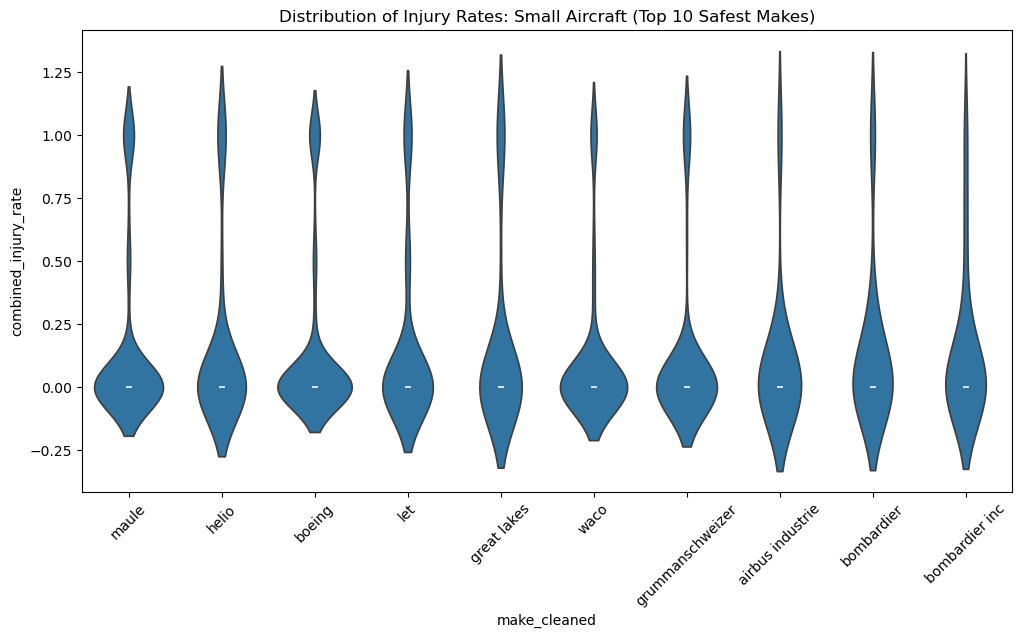

In [302]:
# Violin plot

plt.figure(figsize=(12,6))

sns.violinplot(
    data=small_top10,
    x='make_cleaned',
    y='combined_injury_rate'
)

plt.xticks(rotation=45)
plt.title("Distribution of Injury Rates: Small Aircraft (Top 10 Safest Makes)")
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

In [303]:
# Filter large aircraft
large = df5[df5['aircraft_size'] == 'large'].copy()

In [304]:
# Create combined injury rate
large['combined_injury_rate'] = (
    large['serious_injury_rate'] + large['fatal_injury_rate']
)

In [305]:
# Mean injury rate per make
large_make_rates = (
    large.groupby('make_cleaned')['combined_injury_rate']
    .mean()
    .reset_index()
    .rename(columns={'combined_injury_rate': 'mean_injury_rate'})
)

In [306]:
# Select 10 safest
safe_large_makes = (
    large_make_rates
    .sort_values('mean_injury_rate')
    .head(10)['make_cleaned']
)

In [307]:
# Filter large dataset
large_top10 = large[large['make_cleaned'].isin(safe_large_makes)].copy()

In [308]:
# Confirm
print(large_top10.shape)
print(large_top10['make_cleaned'].nunique())

(36, 39)
10


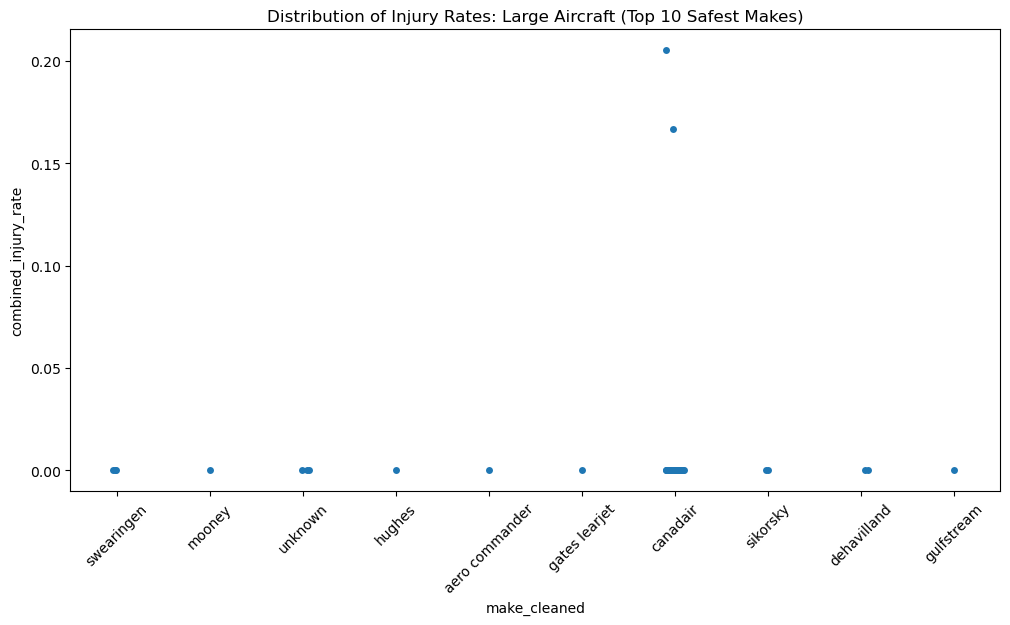

In [309]:
# Strip plot

plt.figure(figsize=(12,6))

sns.stripplot(
    data=large_top10,
    x='make_cleaned',
    y='combined_injury_rate',
    jitter=True
)

plt.xticks(rotation=45)
plt.title("Distribution of Injury Rates: Large Aircraft (Top 10 Safest Makes)")
plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [310]:
small = df5[df5['aircraft_size'] == 'small'].copy()
large = df5[df5['aircraft_size'] == 'large'].copy()

In [311]:
# Destruction rate by small make
small_destruction = (
    small.groupby('make_cleaned')['destroyed_flag']
    .mean()
    .reset_index()
    .rename(columns={'destroyed_flag': 'mean_destruction_rate'})
)

In [312]:
# Destruction rate by large
large_destruction = (
    large.groupby('make_cleaned')['destroyed_flag']
    .mean()
    .reset_index()
    .rename(columns={'destroyed_flag': 'mean_destruction_rate'})
)

In [313]:
# Sort and keep lowest 15
small_best15 = small_destruction.sort_values('mean_destruction_rate').head(15)
large_best15 = large_destruction.sort_values('mean_destruction_rate').head(15)

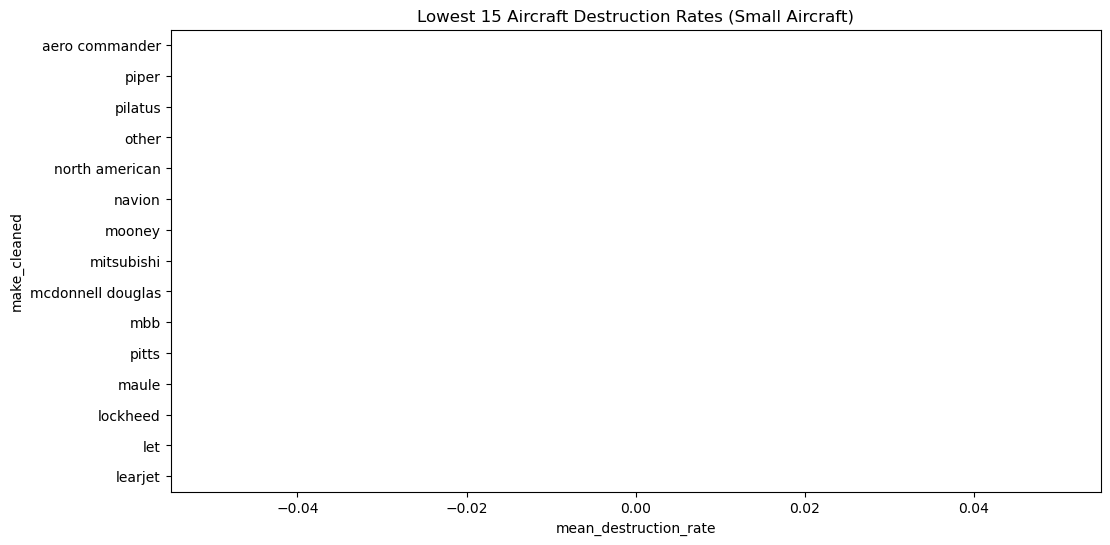

In [314]:
# Small aircraft

plt.figure(figsize=(12,6))

sns.barplot(
    data=small_best15,
    x='mean_destruction_rate',
    y='make_cleaned'
)

plt.title("Lowest 15 Aircraft Destruction Rates (Small Aircraft)")
plt.show()

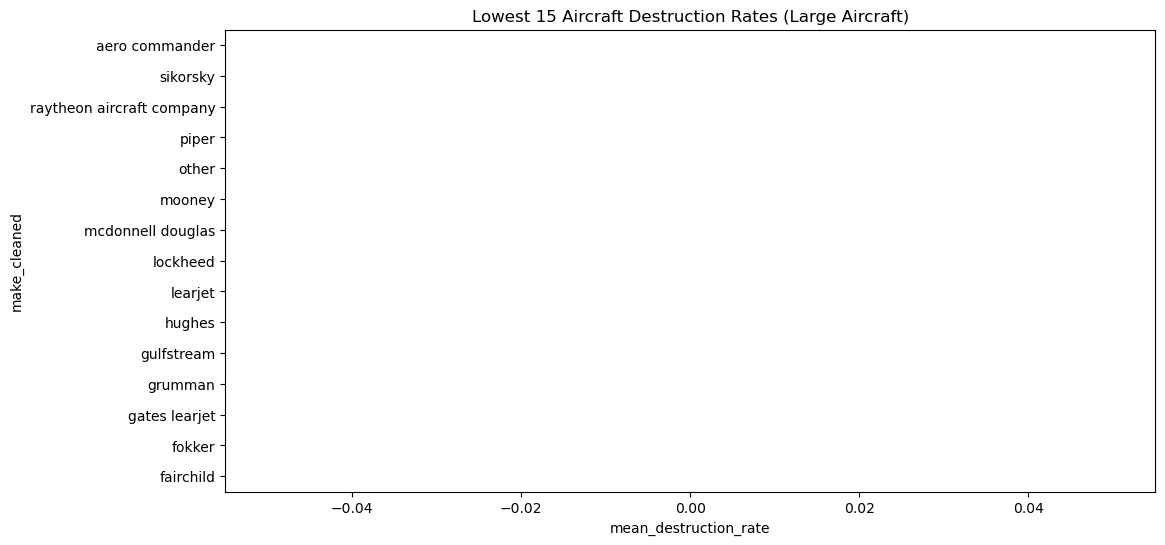

In [315]:
# Large aircraft
plt.figure(figsize=(12,6))

sns.barplot(
    data=large_best15,
    x='mean_destruction_rate',
    y='make_cleaned'
)

plt.title("Lowest 15 Aircraft Destruction Rates (Large Aircraft)")
plt.show()

In [316]:
df5.groupby('make_cleaned')['destroyed_flag'].mean().head(10)

make_cleaned
aero commander      0.0
aeronca             0.0
aerospatiale        0.0
aerostar            0.0
agusta              0.0
air tractor         0.0
air tractor inc     0.0
airbus              0.0
airbus industrie    0.0
american            0.0
Name: destroyed_flag, dtype: float64

In [317]:
df5[df5['destroyed_flag'] == 1].shape

(0, 38)

In [318]:
df5['destroyed_flag'] = (df5['aircraft_damage'] == 'destroyed')


In [319]:
df5['aircraft_damage'].value_counts()

aircraft_damage
Substantial    61482
Destroyed      17462
unknown         2528
Minor           2366
Unknown           92
Name: count, dtype: int64

In [320]:
df5['destroyed_flag'] = df5['aircraft_damage'].str.lower().str.contains('destroy')

In [321]:
df5['destroyed_flag'].value_counts()

destroyed_flag
False    66468
True     17462
Name: count, dtype: int64

In [322]:
df5['aircraft_size'].value_counts()

aircraft_size
small    81180
large     2750
Name: count, dtype: int64

In [323]:
df5['total_aboard_est'].describe()

count    83930.000000
mean         6.294912
std         28.497556
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max        699.000000
Name: total_aboard_est, dtype: float64

In [324]:
small = df5[df5['aircraft_size'] == 'small']
large = df5[df5['aircraft_size'] == 'large']

print(small.shape)
print(large.shape)

(81180, 38)
(2750, 38)


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

In [325]:
large = df5[df5['aircraft_size'] == 'large'].copy()

large['injury_fraction'] = (
    large['fatal_injury_rate'] + large['serious_injury_rate']
)

large = large.dropna(subset=['injury_fraction', 'make_cleaned'])

In [326]:
# Mean
make_means_large = (
    large.groupby('make_cleaned')['injury_fraction']
    .mean()
    .reset_index()
    .rename(columns={'injury_fraction': 'mean_injury_fraction'})
)

In [327]:
safe_10_large = (
    make_means_large
    .sort_values('mean_injury_fraction')
    .head(10)['make_cleaned']
)

large_top10 = large[large['make_cleaned'].isin(safe_10_large)]

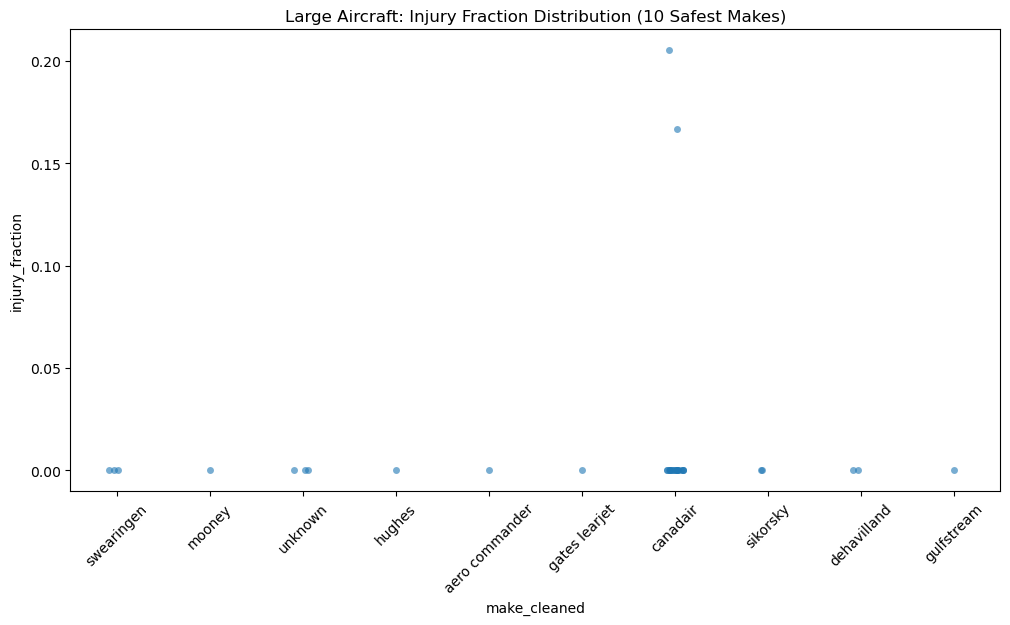

In [328]:
#stripplot

plt.figure(figsize=(12,6))

sns.stripplot(
    data=large_top10,
    x='make_cleaned',
    y='injury_fraction',
    jitter=True,
    alpha=0.6
)

plt.xticks(rotation=45)
plt.title("Large Aircraft: Injury Fraction Distribution (10 Safest Makes)")
plt.show()

In [329]:
df5['aircraft_size'].value_counts()

aircraft_size
small    81180
large     2750
Name: count, dtype: int64

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

In [330]:
small = df5[df5['aircraft_size'] == 'small'].copy()
small['injury_fraction'] = (
    small['fatal_injury_rate'] + small['serious_injury_rate']
)

small = small.dropna(subset=['injury_fraction', 'make_cleaned'])


In [331]:
# Mean
make_means = (
    small.groupby('make_cleaned')['injury_fraction']
    .mean()
    .reset_index()
    .rename(columns={'injury_fraction': 'mean_injury_fraction'})
)

In [332]:
safe_10_makes = (
    make_means
    .sort_values('mean_injury_fraction')
    .head(10)['make_cleaned']
)

In [333]:
# filter original dataset
small_top10 = small[small['make_cleaned'].isin(safe_10_makes)]

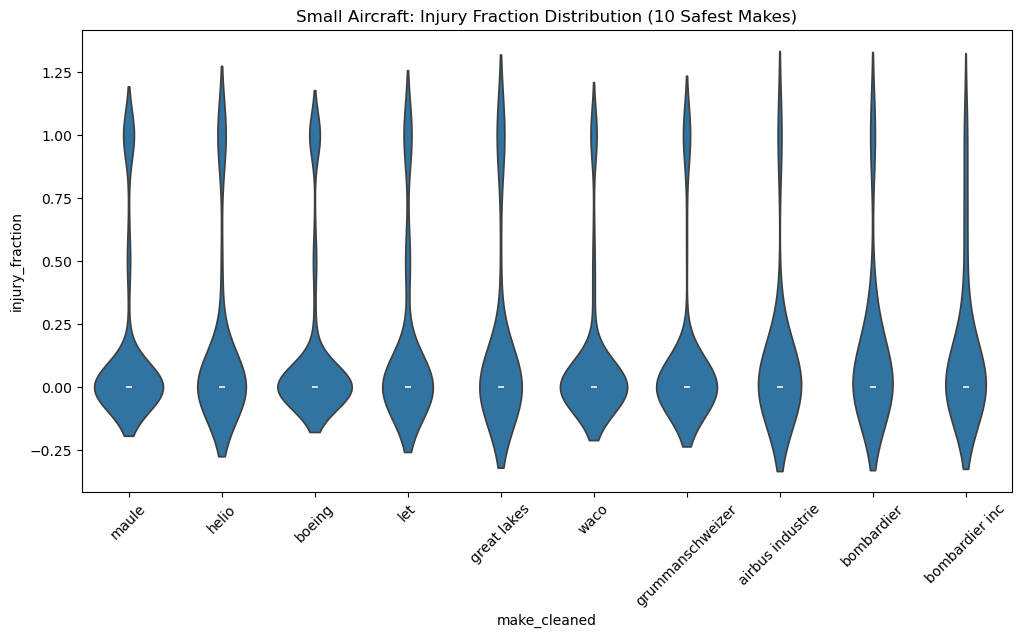

In [334]:
# Violin plot
plt.figure(figsize=(12,6))

sns.violinplot(
    data=small_top10,
    x='make_cleaned',
    y='injury_fraction'
)

plt.xticks(rotation=45)
plt.title("Small Aircraft: Injury Fraction Distribution (10 Safest Makes)")
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.